Author : [ Snorre Johnsen ]
Course : Numerical Scientific Computing 2026

# Milestone 1 - function level profiling

In [1]:
import numpy as np 
import cProfile, pstats
from mandelbrot import compute_mandelbrot_naive, compute_mandelbrot_vectorized


In [2]:
cProfile.run('compute_mandelbrot_naive(-2, 1, -1.5, 1.5, 1024, 1024)', 'naive_profile.prof')
cProfile.run('compute_mandelbrot_vectorized(-2, 1, -1.5, 1.5, 1024, 1024)', 'numpy_profile.prof')

for name in ('naive_profile.prof', 'numpy_profile.prof'):
    stats = pstats.Stats(name)
    stats.sort_stats('cumulative')
    stats.print_stats(10)


Fri Feb 27 10:09:11 2026    naive_profile.prof

         23008341 function calls in 12.611 seconds

   Ordered by: cumulative time
   List reduced from 20 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   12.611   12.611 {built-in method builtins.exec}
        1    0.000    0.000   12.611   12.611 <string>:1(<module>)
        1    2.971    2.971   12.610   12.610 /home/snorre/Desktop/es8/courses/nsc-course/mandelbrot-nsc/mandelbrot.py:51(compute_mandelbrot_naive)
  1048576    7.564    0.000    9.637    0.000 /home/snorre/Desktop/es8/courses/nsc-course/mandelbrot-nsc/mandelbrot.py:25(mandelbrot_point_naive)
 21959734    2.074    0.000    2.074    0.000 {built-in method builtins.abs}
        2    0.001    0.001    0.002    0.001 /home/snorre/miniforge3/envs/nsc2026/lib/python3.11/site-packages/numpy/_core/function_base.py:26(linspace)
        1    0.000    0.000    0.000    0.000 {built-in method numpy.zer

#### Which function takes most total time?
for the naive impolementaion it is the mandelbrot_point function.

i cannot see the numpy profiling it seems as the cprofiler cannot do it on numpy.

#### Are there functions called surprisingly many times?
the python abs() function is called alot of times (21959734 times)
#### How does the NumPy profile compare to naive?
as mentioned before cProfiler cannot seem to read numpy but the numpy is significantly faster

# Milestone 2

tried both with @profile and line_profiler.profile

seems to get roughly same result

below is the whole funciton

# Profiling section

1. cProfile on naive vs NumPy: How many functions appear in each profile? What does
this difference tell you about where the work actually happens?

naive: 23008341 function calls in 13.179 seconds

numpy: 81 function calls in 1.677 seconds

it difficult to say since cProfiler hides most of the computation since it cannot "see" it 

2. line profiler on naive: Which lines dominate runtime? What fraction of total time is
spent in the inner loop?

the abs() line is what takes the most time with 39.4 % followed by the z update line taking 37.4% of time in the inner loop. 

for the last line profiler it says the innerloop(mandelbrot_point) is roughly responsible for 90.4% of the runtime


3. Based on your profiling results: why is NumPy faster than naive Python?

Numpy is faster since it vectorizes the operations utilizing SIMD cutting time used doing the calculations in the inner loop as shown. 



4. What would you need to change to make the naive version faster? (hint: what does
line profiler tell you about the inner loop?)

i would need to find another way of doing the if abs() statement since in takes alot of time. also look into the z update since it loops over the same operation alot of times.


# Milestone 3 Numba implementation

In [93]:
from numba import njit, prange

@njit
def mandelbrot_point_numba (c) :
    """
    computes one mandelbrot point

    Parameters
    ----------
    c : complex
        complex constant
    
    Returns
    -------
    n : int 
        iterations
    """

    z = 0j 
    max_iter = 100

    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z**2 + c
    return n


def compute_mandelbrot_numba_hybrid (x_min, x_max, y_min, y_max, resx, resy):
    #create evenly spaced numbers
    x = np.linspace(x_min, x_max, resx)
    y = np.linspace(y_min, y_max, resy)

    #create arrays for iterations
    all_n = np.zeros((resx, resy), dtype = np.int32)

    for i in range(resx):
        for j in range(resy):
            c = x[i] + 1j * y[j]
            all_n[i, j] = mandelbrot_point_numba(c)
    return all_n

@njit
def compute_mandelbrot_numba(x_min, x_max, y_min, y_max, resx, resy):
    """
    compute mandelbrot set over 2d region numba implementation

    Parameters
    ----------
    x_min : float
        minimum real value of region
    x_max : float
        maximum real value of region 
    y_min : float
        minimum imaginary value of region
    y_max : float
        maximum imaginary value of region 
    resx : int
        number of points in x-axis
    resy : int
        number of points in y-axis
    
    Returns
    -------
    all_n : numpy.ndarray of shape (resx, resy)
        2d array containing number of iterations before magnitude grows too large for each point in the complex grid
    """

    #create evenly spaced numbers
    x = np.linspace(x_min, x_max, resx)
    y = np.linspace(y_min, y_max, resy)

    #create arrays for iterations
    all_n = np.zeros((resx, resy), dtype = np.int32)

    for i in range(resx):
        for j in range(resy):
            c = x[i] + 1j * y[j]
            all_n[i, j] = mandelbrot_point_numba(c)
    return all_n


# parrrallel version

@njit(parallel=True)
def mandelbrot_point_numba_par (c) :
    z = 0j 
    max_iter = 100

    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z**2 + c
    return n

@njit(parallel=True)
def compute_mandelbrot_numba_par(x_min, x_max, y_min, y_max, resx, resy):
    #create evenly spaced numbers
    x = np.linspace(x_min, x_max, resx)
    y = np.linspace(y_min, y_max, resy)

    #create arrays for iterations
    all_n = np.zeros((resx, resy), dtype = np.int32)

    for i in range(resx):
        for j in range(resy):
            c = x[i] + 1j * y[j]
            all_n[i, j] = mandelbrot_point_numba(c)
    return all_n

In [94]:
import time
from mandelbrot import benchmark

_ = compute_mandelbrot_numba(-2, 1, -1.5, 1.5, 1024, 1024) # warmup for numba

elaptime_numba, mandelbrot_numba_out = benchmark(compute_mandelbrot_numba, -2, 1, -1.5, 1.5, 1024, 1024, n_runs=10)
elaptime_numba_hybrid, mandelbrot_numba_hybrid_out = benchmark(compute_mandelbrot_numba_hybrid, -2, 1, -1.5, 1.5, 1024, 1024, n_runs=10)
print(f"Fully compiled Computation took {elaptime_numba:.3f} seconds")
print(f"Hybrid Computation took {elaptime_numba_hybrid:.3f} seconds")
print(f"Ratio: {elaptime_numba_hybrid/elaptime_numba}")

_ = compute_mandelbrot_numba_par(-2, 1, -1.5, 1.5, 1024, 1024) # warmup for numba
elaptime_numba_par, mandelbrot_numba_par_out = benchmark(compute_mandelbrot_numba_par, -2, 1, -1.5, 1.5, 1024, 1024, n_runs=10)
print(f"Parallel Computation took {elaptime_numba_par:.3f} seconds")
print(f"Ratio parallel: {elaptime_numba_par/elaptime_numba}")

Median : 0.0741 s ( min =0.0724 , max =0.0823)
Median : 1.9018 s ( min =1.8786 , max =1.9905)
Fully compiled Computation took 0.074 seconds
Hybrid Computation took 1.902 seconds
Ratio: 25.673918688285905
Median : 0.0723 s ( min =0.0716 , max =0.0758)
Parallel Computation took 0.072 seconds
Ratio parallel: 0.9754747743603008


In [12]:
import statistics


def bench(fn, *args, runs=5):
    fn(*args)  # warm-up
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn(*args)
        times.append(time.perf_counter() - t0)
    return statistics.median(times)


_ = compute_mandelbrot_numba(-2, 1, -1.5, 1.5, 1024, 1024)  # warmup for numba

width, height = 1024, 1024
args = (-2, 1, -1.5, 1.5, width, height)

t_naive = bench(compute_mandelbrot_naive, *args)
t_numpy = bench(compute_mandelbrot_vectorized, *args)
t_numba = bench(compute_mandelbrot_numba, *args)

print(f"Naive: {t_naive:.3f} s")
print(f"NumPy: {t_numpy:.3f} s ({t_naive / t_numpy:.1f}x)")
print(f"Numba: {t_numba:.3f} s ({t_naive / t_numba:.1f}x)")

Naive: 6.856 s
NumPy: 1.510 s (4.5x)
Numba: 0.072 s (94.8x)


# Milestone 4 data type optimization

In [26]:
@njit
def mandelbrot_point_numba_typed (c) :
    z = 0j 
    max_iter = 100

    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z**2 + c
    return n

@njit
def compute_mandelbrot_numba_typed(x_min, x_max, y_min, y_max, resx, resy, dtype=np.float64):
    #create evenly spaced numbers
    x = np.linspace(x_min, x_max, resx).astype(dtype)
    y = np.linspace(y_min, y_max, resy).astype(dtype)

    #create arrays for iterations
    all_n = np.zeros((resx, resy), dtype = np.int32)

    for i in range(resx):
        for j in range(resy):
            c = x[i] + 1j * y[j]
            all_n[i, j] = mandelbrot_point_numba_typed(c)
    return all_n

In [91]:
for dtype in [np.float32, np.float64]:
    t0 = time.perf_counter()
    compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, dtype=dtype)
    print(f"{dtype.__name__}: {time.perf_counter()-t0:.3f}s")

float32: 0.079s
float64: 0.076s


Max diff float32 vs float64: 32


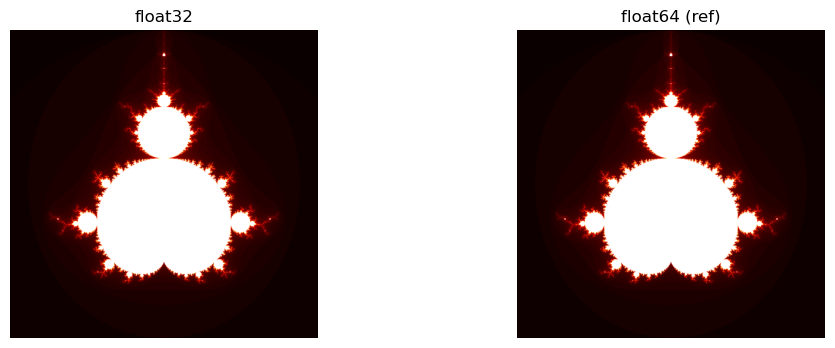

In [73]:
import matplotlib.pyplot as plt

r32 = compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, dtype=np.float32)
r64 = compute_mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 1024, 1024, dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, result, title in zip(axes, [r32, r64],
                             ['float32', 'float64 (ref)']):
    ax.imshow(result, cmap='hot')
    ax.set_title(title); ax.axis('off')
plt.savefig('precision_comparison.png', dpi=150)

print(f"Max diff float32 vs float64: {np.abs(r32-r64).max()}")


float 32 is not nessecarily faster then the float 64 so i would hesitate to just make it float32. and i can see little difference between the pictures. 

# Milestone 5

tried paralell did not see any speedup